In [3]:
import numpy as np # linear algebra
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/fake-news-detection/true.csv
/kaggle/input/fake-news-detection/fake.csv


In [4]:
true = pd.read_csv('/kaggle/input/fake-news-detection/true.csv')

In [5]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
true.shape

(21417, 4)

In [7]:
fake = pd.read_csv('/kaggle/input/fake-news-detection/fake.csv')

In [8]:
fake.shape

(23481, 4)

In [9]:
true['label'] = 1
fake['label'] = 0

In [10]:
frames = [true.loc[:5000][:], fake.loc[:5000][:]]

In [11]:
df = pd.concat(frames)

In [12]:
df.shape

(10002, 5)

In [13]:
X = df. drop('label', axis=1)
y = df['label']

In [14]:
df = df.dropna()
df2 = df.copy()

In [15]:
df2.reset_index(inplace=True)
df2.head()

,index,title,text,subject,date,label
0,0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [16]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [18]:
import re
import nltk
nltk.download('stopwords')

corpus = []
for i in range(0, len(df2)):
    review = re.sub('[^a-zA-Z]', ' ', df2['text'][i])
    review = review.lower()
    review = review.split()
    
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_v = TfidfVectorizer(max_features=5000, ngram_range=(1,3))

In [21]:
X = tfidf_v.fit_transform(corpus).toarray()
y = df2['label']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [23]:
from sklearn.linear_model import PassiveAggressiveClassifier
classifier = PassiveAggressiveClassifier(max_iter=1000)

In [24]:
from sklearn import metrics
import numpy as np
import itertools

classifier.fit(X_train, y_train)

pred = classifier.predict(X_test)

score = metrics.accuracy_score(y_test, pred)
print("accuracy:   %0.3f" % score)

accuracy:   0.999


In [25]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,normalize=False,title='Confusion matrix',cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization


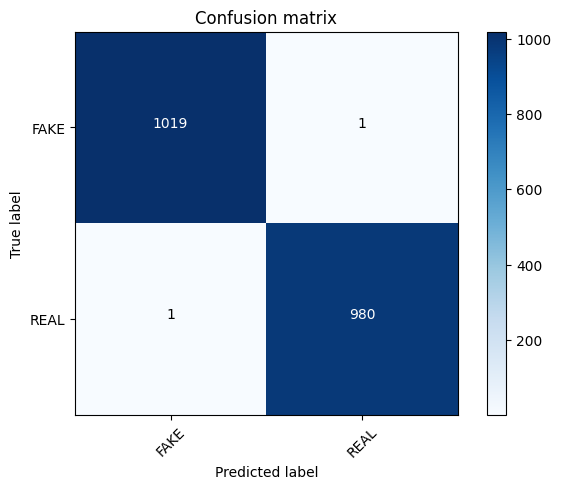

In [26]:
cm = metrics.confusion_matrix(y_test, pred)
plot_confusion_matrix(cm, classes=['FAKE', 'REAL'])

In [27]:
review = re.sub('[^a-zA-Z]', ' ', fake['text'][13070])
review = review.lower()
review = review.split()
    
review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
review = ' '.join(review)
review

'mani c word hillari compet one ouch'

In [28]:
val = tfidf_v.transform([review]).toarray()

In [29]:
classifier.predict(val)

array([0])

In [30]:
import pickle
pickle.dump(classifier, open('model2.pkl', 'wb'))
pickle.dump(tfidf_v, open('tfidfvect2.pkl', 'wb'))

In [31]:
joblib_model = pickle.load(open('model2.pkl', 'rb'))
joblib_vect = pickle.load(open('tfidfvect2.pkl', 'rb'))
val_pkl = joblib_vect.transform([review]).toarray()
test_pred = joblib_model.predict(val_pkl)

if test_pred == 0:
    print("Fake News!")
else:
    print("Real News")

Fake News!


In [33]:
import re
import pickle
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

def test_news(news_text):
    # Initialize Porter Stemmer
    ps = PorterStemmer()

    # Preprocess the input news
    review = re.sub('[^a-zA-Z]', ' ', news_text)  # Remove non-alphabet characters
    review = review.lower()  # Convert to lowercase
    review = review.split()  # Tokenize into words
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]  # Remove stopwords and stem words
    review = ' '.join(review)  # Recombine into a single string

    # Load the trained model and vectorizer
    joblib_model = pickle.load(open('model2.pkl', 'rb'))
    joblib_vect = pickle.load(open('tfidfvect2.pkl', 'rb'))

    # Transform using the loaded vectorizer
    val = joblib_vect.transform([review]).toarray()

    # Predict using the loaded model
    prediction = joblib_model.predict(val)

    # Output the result
    if prediction == 0:
        return "Fake News!"
    else:
        return "Real News!"


In [34]:
news_text = "Breaking news: Scientists discover a new element that could revolutionize technology!"

# Test the news
result = test_news(news_text)
print(result)

Fake News!


In [36]:
# Test a sample news article
news_text = """
NASA's latest mission has successfully landed on Mars, bringing back valuable data 
about the Red Planet's atmosphere and surface conditions. Scientists are excited 
about the findings, which could pave the way for future human exploration.
"""
result = test_news(news_text)
print(f"Prediction for the sample news: {result}")

Prediction for the sample news: Fake News!


In [37]:
news_text = """
World leaders gathered in New York for the annual United Nations General Assembly to discuss global issues, 
including climate change, international security, and economic development. The Secretary-General urged 
countries to work together to meet the targets set by the Paris Agreement, emphasizing the importance of 
collaborative efforts in combating global warming. The assembly also highlighted the ongoing challenges 
faced by developing nations and the need for increased support from the international community.
"""
result = test_news(news_text)
print(f"Prediction for the real news: {result}")


Prediction for the real news: Real News!


In [47]:
news_text = """
LDF and UDF find themselves on the same side as legal and political battle lines emerge over draft UGC regulations
"""
result = test_news(news_text)
print(f"Prediction for the real news: {result}")


Prediction for the real news: Real News!


In [41]:
news_text = """
Jaishankar to represent India at Donald Trump’s swearing-in as US President on January 20
 """
result = test_news(news_text)
print(f"Prediction for the real news: {result}")


Prediction for the real news: Real News!


In [54]:
news_text = """
Game Changer Box Office Collection Day 2: Amid Accusations Of Inflating Numbers, Ram Charan And Kiara Advani's Film Faces A Roadblock
 """
result = test_news(news_text)
print(f"Prediction for the real news: {result}")

Prediction for the real news: Real News!


In [62]:
news_text = """
A thick blanket of fog covered the national capital on Sunday (January 12, 2025), as the city experienced a cold spell.
 """
result = test_news(news_text)
print(f"Prediction for the real news: {result}")

Prediction for the real news: Real News!
